In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
print("Building Content-Based Recommender using TF-IDF")

✅ Libraries imported successfully!
Building Content-Based Recommender using TF-IDF


In [2]:
# Load cleaned data
ratings = pd.read_csv('../data/processed/ratings_clean.csv')
movies = pd.read_csv('../data/processed/movies_clean.csv')

print("✅ Data loaded successfully!")
print(f"Ratings: {ratings.shape}")
print(f"Movies: {movies.shape}")
print(f"\nSample movies:")
print(movies.head())

✅ Data loaded successfully!
Ratings: (100836, 7)
Movies: (9742, 3)

Sample movies:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [3]:
print("="*70)
print("PREPARING CONTENT FEATURES")
print("="*70)

# Combine genres into a single string (content feature)
movies['content'] = movies['genres'].str.replace('|', ' ')

print(f"\n✅ Content features created from genres")
print(f"\nSample content:")
for idx, row in movies.head(5).iterrows():
    print(f"  {row['title']}: {row['content']}")

PREPARING CONTENT FEATURES

✅ Content features created from genres

Sample content:
  Toy Story (1995): Adventure Animation Children Comedy Fantasy
  Jumanji (1995): Adventure Children Fantasy
  Grumpier Old Men (1995): Comedy Romance
  Waiting to Exhale (1995): Comedy Drama Romance
  Father of the Bride Part II (1995): Comedy


In [4]:
print("\n" + "="*70)
print("CREATING TF-IDF MATRIX")
print("="*70)

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=100,  # Limit to top 100 features
    ngram_range=(1, 1)  # Unigrams only
)

# Fit and transform the content
tfidf_matrix = tfidf.fit_transform(movies['content'])

print(f"\n✅ TF-IDF matrix created")
print(f"Matrix shape: {tfidf_matrix.shape}")
print(f"  - {tfidf_matrix.shape[0]} movies")
print(f"  - {tfidf_matrix.shape[1]} features (genre terms)")

# Show feature names
feature_names = tfidf.get_feature_names_out()
print(f"\nTop 20 features (genre terms):")
print(feature_names[:20])


CREATING TF-IDF MATRIX

✅ TF-IDF matrix created
Matrix shape: (9742, 23)
  - 9742 movies
  - 23 features (genre terms)

Top 20 features (genre terms):
['action' 'adventure' 'animation' 'children' 'comedy' 'crime'
 'documentary' 'drama' 'fantasy' 'fi' 'film' 'genres' 'horror' 'imax'
 'listed' 'musical' 'mystery' 'noir' 'romance' 'sci']


In [5]:
print("\n" + "="*70)
print("CALCULATING CONTENT SIMILARITY MATRIX")
print("="*70)

import time
start_time = time.time()

# Compute cosine similarity between all movies
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

computation_time = time.time() - start_time

print(f"\n✅ Similarity matrix computed in {computation_time:.2f} seconds")
print(f"Matrix shape: {cosine_sim.shape}")
print(f"Matrix size: {cosine_sim.nbytes / (1024**2):.2f} MB")

# Show sample similarities
print(f"\nSample similarities for first movie:")
sample_movie = movies.iloc[0]
print(f"Movie: {sample_movie['title']}")
print(f"Top 5 most similar movies (by content):")
similar_indices = cosine_sim[0].argsort()[-6:-1][::-1]  # Top 5 (excluding itself)
for idx in similar_indices:
    print(f"  - {movies.iloc[idx]['title']} (similarity: {cosine_sim[0][idx]:.4f})")


CALCULATING CONTENT SIMILARITY MATRIX

✅ Similarity matrix computed in 0.21 seconds
Matrix shape: (9742, 9742)
Matrix size: 724.08 MB

Sample similarities for first movie:
Movie: Toy Story (1995)
Top 5 most similar movies (by content):
  - Emperor's New Groove, The (2000) (similarity: 1.0000)
  - Antz (1998) (similarity: 1.0000)
  - Adventures of Rocky and Bullwinkle, The (2000) (similarity: 1.0000)
  - Wild, The (2006) (similarity: 1.0000)
  - Asterix and the Vikings (Astérix et les Vikings) (2006) (similarity: 1.0000)


In [6]:
# Create movie index mapping for fast lookup
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

def get_content_recommendations(title, cosine_sim=cosine_sim, n=10):
    """
    Get similar movies based on content (genres)
    
    Parameters:
    - title: Movie title
    - cosine_sim: Precomputed similarity matrix
    - n: Number of recommendations
    
    Returns:
    - List of similar movies with similarity scores
    """
    try:
        # Get index of movie that matches title
        idx = indices[title]
        
        # Get pairwise similarity scores
        sim_scores = list(enumerate(cosine_sim[idx]))
        
        # Sort movies by similarity score
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        
        # Get top N similar movies (excluding itself)
        sim_scores = sim_scores[1:n+1]
        
        # Get movie indices
        movie_indices = [i[0] for i in sim_scores]
        
        # Create recommendations list
        recommendations = []
        for idx, score in sim_scores:
            recommendations.append({
                'movieId': movies.iloc[idx]['movieId'],
                'title': movies.iloc[idx]['title'],
                'genres': movies.iloc[idx]['genres'],
                'similarity_score': score
            })
        
        return recommendations
    
    except KeyError:
        return f"Movie '{title}' not found in database"

print("✅ Content-based recommendation function created!")

✅ Content-based recommendation function created!


In [7]:
print("\n" + "="*70)
print("TESTING CONTENT-BASED RECOMMENDATIONS")
print("="*70)

# Test with different movies
test_movies = [
    "Toy Story (1995)",
    "Jurassic Park (1993)",
    "Pulp Fiction (1994)",
    "Matrix, The (1999)"
]

for test_movie in test_movies:
    print(f"\n{'='*70}")
    print(f"Movies similar to: {test_movie}")
    print(f"{'='*70}")
    
    # Get movie info
    movie_info = movies[movies['title'] == test_movie].iloc[0]
    print(f"Original genres: {movie_info['genres']}")
    
    # Get recommendations
    recs = get_content_recommendations(test_movie, n=5)
    
    print(f"\nTop 5 Similar Movies:")
    for i, rec in enumerate(recs, 1):
        print(f"{i}. {rec['title']}")
        print(f"   Genres: {rec['genres']}")
        print(f"   Similarity: {rec['similarity_score']:.4f}")


TESTING CONTENT-BASED RECOMMENDATIONS

Movies similar to: Toy Story (1995)
Original genres: Adventure|Animation|Children|Comedy|Fantasy

Top 5 Similar Movies:
1. Antz (1998)
   Genres: Adventure|Animation|Children|Comedy|Fantasy
   Similarity: 1.0000
2. Toy Story 2 (1999)
   Genres: Adventure|Animation|Children|Comedy|Fantasy
   Similarity: 1.0000
3. Adventures of Rocky and Bullwinkle, The (2000)
   Genres: Adventure|Animation|Children|Comedy|Fantasy
   Similarity: 1.0000
4. Emperor's New Groove, The (2000)
   Genres: Adventure|Animation|Children|Comedy|Fantasy
   Similarity: 1.0000
5. Monsters, Inc. (2001)
   Genres: Adventure|Animation|Children|Comedy|Fantasy
   Similarity: 1.0000

Movies similar to: Jurassic Park (1993)
Original genres: Action|Adventure|Sci-Fi|Thriller

Top 5 Similar Movies:
1. Independence Day (a.k.a. ID4) (1996)
   Genres: Action|Adventure|Sci-Fi|Thriller
   Similarity: 1.0000
2. Escape from L.A. (1996)
   Genres: Action|Adventure|Sci-Fi|Thriller
   Similarity: 1


GENRE SIMILARITY ANALYSIS
Total unique genres: 19
Genres: Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, IMAX, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western


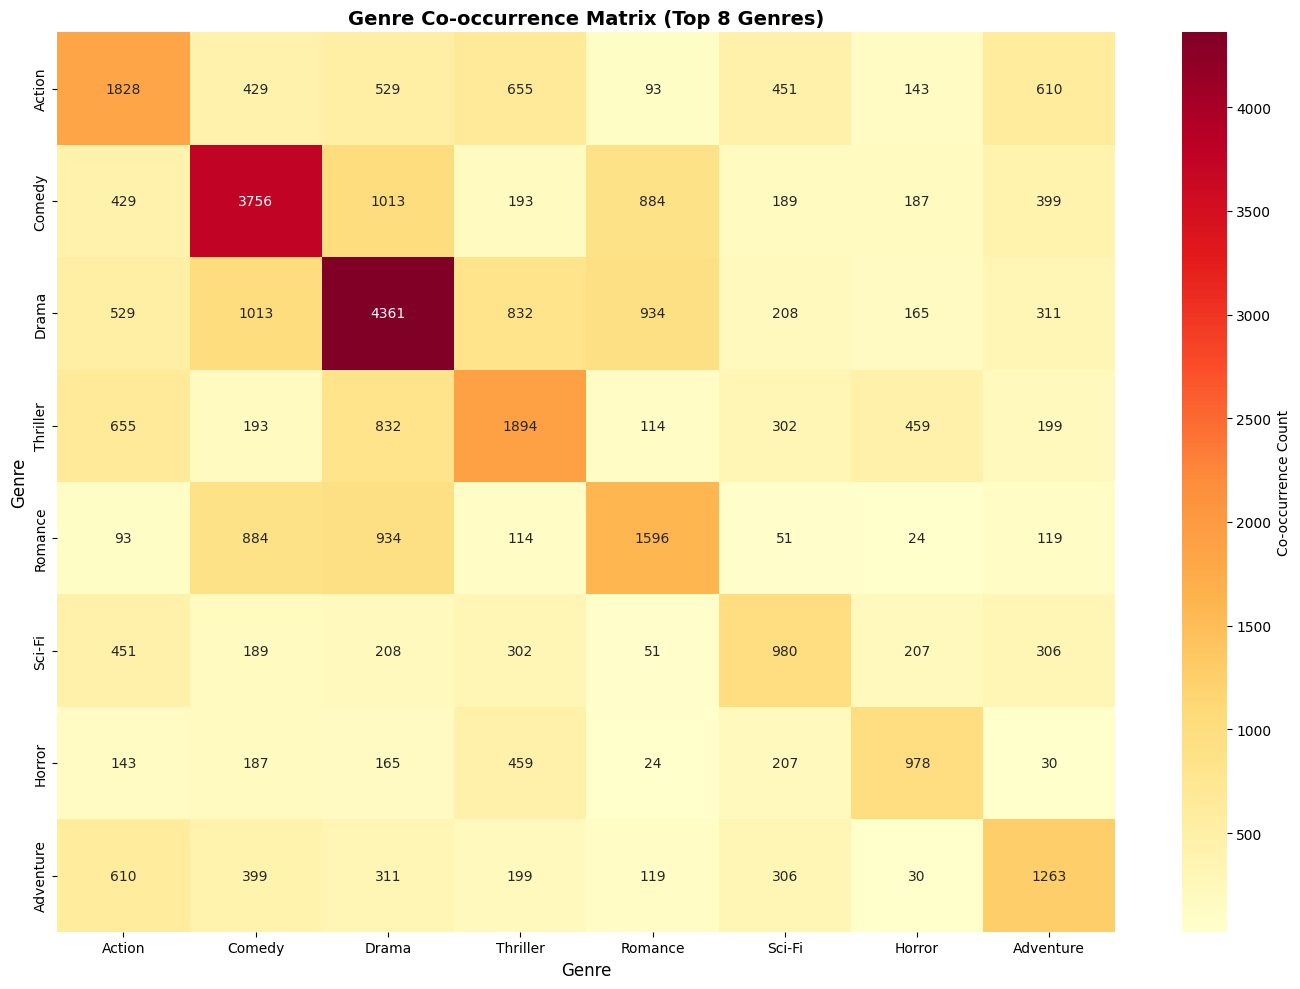

In [8]:
print("\n" + "="*70)
print("GENRE SIMILARITY ANALYSIS")
print("="*70)

# Get all unique genres
all_genres = set()
for genre_str in movies['genres']:
    genres = genre_str.split('|')
    all_genres.update(genres)

all_genres.discard('(no genres listed)')
all_genres = sorted(list(all_genres))

print(f"Total unique genres: {len(all_genres)}")
print(f"Genres: {', '.join(all_genres)}")

# Create genre co-occurrence matrix
genre_cooccurrence = pd.DataFrame(0, index=all_genres, columns=all_genres)

for idx, row in movies.iterrows():
    genres = row['genres'].split('|')
    for g1 in genres:
        if g1 in all_genres:
            for g2 in genres:
                if g2 in all_genres:
                    genre_cooccurrence.loc[g1, g2] += 1

# Visualize top genre combinations
plt.figure(figsize=(14, 10))
top_genres = ['Action', 'Comedy', 'Drama', 'Thriller', 'Romance', 'Sci-Fi', 'Horror', 'Adventure']
subset = genre_cooccurrence.loc[top_genres, top_genres]

sns.heatmap(subset, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Co-occurrence Count'})
plt.title('Genre Co-occurrence Matrix (Top 8 Genres)', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
def get_user_content_recommendations(user_id, n=10):
    """
    Get content-based recommendations for a user
    Based on genres of movies they've rated highly
    
    Parameters:
    - user_id: User ID
    - n: Number of recommendations
    
    Returns:
    - List of recommended movies
    """
    # Get user's highly rated movies (rating >= 4.0)
    user_ratings = ratings[ratings['userId'] == user_id]
    high_ratings = user_ratings[user_ratings['rating'] >= 4.0]
    
    if len(high_ratings) == 0:
        return "User has no high ratings (>= 4.0)"
    
    # Get movie titles for high ratings
    high_rated_movies = movies[movies['movieId'].isin(high_ratings['movieId'])]
    
    # Get content-based recommendations for each highly rated movie
    all_recommendations = {}
    
    for idx, movie in high_rated_movies.iterrows():
        similar_movies = get_content_recommendations(movie['title'], n=20)
        
        for rec in similar_movies:
            movie_id = rec['movieId']
            if movie_id not in high_ratings['movieId'].values:  # Not already rated
                if movie_id not in all_recommendations:
                    all_recommendations[movie_id] = {
                        'title': rec['title'],
                        'genres': rec['genres'],
                        'total_similarity': 0,
                        'count': 0
                    }
                all_recommendations[movie_id]['total_similarity'] += rec['similarity_score']
                all_recommendations[movie_id]['count'] += 1
    
    # Calculate average similarity
    for movie_id in all_recommendations:
        avg_sim = all_recommendations[movie_id]['total_similarity'] / all_recommendations[movie_id]['count']
        all_recommendations[movie_id]['avg_similarity'] = avg_sim
    
    # Sort by average similarity
    sorted_recs = sorted(all_recommendations.items(), 
                        key=lambda x: x[1]['avg_similarity'], 
                        reverse=True)
    
    # Return top N
    top_recs = []
    for movie_id, data in sorted_recs[:n]:
        top_recs.append({
            'movieId': movie_id,
            'title': data['title'],
            'genres': data['genres'],
            'avg_similarity': data['avg_similarity']
        })
    
    return top_recs, high_rated_movies

print("✅ User-based content recommendation function created!")

✅ User-based content recommendation function created!


In [10]:
print("\n" + "="*70)
print("TESTING USER CONTENT-BASED RECOMMENDATIONS")
print("="*70)

test_user = 1

recs, user_favorites = get_user_content_recommendations(test_user, n=10)

print(f"\nUser {test_user}'s Favorite Movies (Rating >= 4.0):")
print("-" * 70)
for idx, movie in user_favorites.iterrows():
    user_rating = ratings[(ratings['userId'] == test_user) & 
                         (ratings['movieId'] == movie['movieId'])].iloc[0]['rating']
    print(f"  ⭐ {user_rating:.1f} - {movie['title']}")
    print(f"       Genres: {movie['genres']}")

print(f"\n\nTop 10 Content-Based Recommendations:")
print("-" * 70)
for i, rec in enumerate(recs, 1):
    print(f"{i:2d}. {rec['title']}")
    print(f"    Genres: {rec['genres']}")
    print(f"    Avg Similarity: {rec['avg_similarity']:.4f}")
    print()


TESTING USER CONTENT-BASED RECOMMENDATIONS

User 1's Favorite Movies (Rating >= 4.0):
----------------------------------------------------------------------
  ⭐ 4.0 - Toy Story (1995)
       Genres: Adventure|Animation|Children|Comedy|Fantasy
  ⭐ 4.0 - Grumpier Old Men (1995)
       Genres: Comedy|Romance
  ⭐ 4.0 - Heat (1995)
       Genres: Action|Crime|Thriller
  ⭐ 5.0 - Seven (a.k.a. Se7en) (1995)
       Genres: Mystery|Thriller
  ⭐ 5.0 - Usual Suspects, The (1995)
       Genres: Crime|Mystery|Thriller
  ⭐ 5.0 - Bottle Rocket (1996)
       Genres: Adventure|Comedy|Crime|Romance
  ⭐ 4.0 - Braveheart (1995)
       Genres: Action|Drama|War
  ⭐ 5.0 - Rob Roy (1995)
       Genres: Action|Drama|Romance|War
  ⭐ 5.0 - Canadian Bacon (1995)
       Genres: Comedy|War
  ⭐ 5.0 - Desperado (1995)
       Genres: Action|Romance|Western
  ⭐ 5.0 - Billy Madison (1995)
       Genres: Comedy
  ⭐ 5.0 - Dumb & Dumber (Dumb and Dumber) (1994)
       Genres: Adventure|Comedy
  ⭐ 4.0 - Ed Wood (1994)
    

In [11]:
print("\n" + "="*70)
print("COMPARISON: CONTENT-BASED vs COLLABORATIVE FILTERING")
print("="*70)

# Load SVD model
with open('../models/svd_model.pkl', 'rb') as f:
    svd_model = pickle.load(f)

# Get recommendations from both methods
test_user = 1

# Content-based
content_recs, _ = get_user_content_recommendations(test_user, n=10)

# Collaborative filtering (reuse function from previous notebook)
def get_cf_recommendations(model, user_id, n=10):
    all_movie_ids = ratings['movieId'].unique()
    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].values
    movies_to_predict = [mid for mid in all_movie_ids if mid not in rated_movies]
    
    predictions = []
    for movie_id in movies_to_predict:
        pred = model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))
    
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_n = predictions[:n]
    
    recommendations = []
    for movie_id, pred_rating in top_n:
        movie_info = movies[movies['movieId'] == movie_id]
        if not movie_info.empty:
            movie_info = movie_info.iloc[0]
            recommendations.append({
                'movieId': movie_id,
                'title': movie_info['title'],
                'genres': movie_info['genres'],
                'predicted_rating': pred_rating
            })
    
    return recommendations

cf_recs = get_cf_recommendations(svd_model, test_user, n=10)

# Compare
print(f"\nUser {test_user} Recommendations Comparison:\n")

print("COLLABORATIVE FILTERING (SVD):")
print("-" * 70)
for i, rec in enumerate(cf_recs, 1):
    print(f"{i:2d}. {rec['title']}")
    print(f"    Predicted Rating: {rec['predicted_rating']:.2f} | Genres: {rec['genres']}")

print("\n\nCONTENT-BASED FILTERING:")
print("-" * 70)
for i, rec in enumerate(content_recs, 1):
    print(f"{i:2d}. {rec['title']}")
    print(f"    Similarity: {rec['avg_similarity']:.4f} | Genres: {rec['genres']}")

# Find overlap
cf_titles = set(r['title'] for r in cf_recs)
cb_titles = set(r['title'] for r in content_recs)
overlap = cf_titles & cb_titles

print(f"\n\nOverlap: {len(overlap)} movies appear in both lists")
if overlap:
    print(f"Common recommendations: {', '.join(overlap)}")


COMPARISON: CONTENT-BASED vs COLLABORATIVE FILTERING

User 1 Recommendations Comparison:

COLLABORATIVE FILTERING (SVD):
----------------------------------------------------------------------
 1. Departed, The (2006)
    Predicted Rating: 5.00 | Genres: Crime|Drama|Thriller
 2. North by Northwest (1959)
    Predicted Rating: 5.00 | Genres: Action|Adventure|Mystery|Romance|Thriller
 3. Casablanca (1942)
    Predicted Rating: 5.00 | Genres: Drama|Romance
 4. Seven Samurai (Shichinin no samurai) (1954)
    Predicted Rating: 5.00 | Genres: Action|Adventure|Drama
 5. Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)
    Predicted Rating: 5.00 | Genres: Comedy|War
 6. Lord of the Rings: The Return of the King, The (2003)
    Predicted Rating: 5.00 | Genres: Action|Adventure|Drama|Fantasy
 7. Blade Runner (1982)
    Predicted Rating: 5.00 | Genres: Action|Sci-Fi|Thriller
 8. One Flew Over the Cuckoo's Nest (1975)
    Predicted Rating: 5.00 | Genres: Drama
 9. Grand 

In [12]:
import os

print("\n" + "="*70)
print("SAVING CONTENT-BASED COMPONENTS")
print("="*70)

# Save TF-IDF vectorizer
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("✅ TF-IDF vectorizer saved to: models/tfidf_vectorizer.pkl")

# Save similarity matrix
np.save('../models/content_similarity_matrix.npy', cosine_sim)
print("✅ Similarity matrix saved to: models/content_similarity_matrix.npy")

# Save movie indices
indices.to_pickle('../models/movie_indices.pkl')
print("✅ Movie indices saved to: models/movie_indices.pkl")

print("\n" + "="*70)
print("✅ CONTENT-BASED FILTERING COMPLETE!")
print("="*70)
print("\nComponents saved:")
print("  • TF-IDF Vectorizer")
print("  • Content Similarity Matrix")
print("  • Movie Title Indices")
print("\n" + "="*70)
print("NEXT STEPS:")
print("="*70)
print("1. Create notebook: 04_hybrid_recommender.ipynb")
print("2. Combine collaborative and content-based approaches")
print("3. Implement weighted hybrid algorithm")
print("4. Evaluate hybrid performance")
print("="*70)


SAVING CONTENT-BASED COMPONENTS
✅ TF-IDF vectorizer saved to: models/tfidf_vectorizer.pkl
✅ Similarity matrix saved to: models/content_similarity_matrix.npy
✅ Movie indices saved to: models/movie_indices.pkl

✅ CONTENT-BASED FILTERING COMPLETE!

Components saved:
  • TF-IDF Vectorizer
  • Content Similarity Matrix
  • Movie Title Indices

NEXT STEPS:
1. Create notebook: 04_hybrid_recommender.ipynb
2. Combine collaborative and content-based approaches
3. Implement weighted hybrid algorithm
4. Evaluate hybrid performance
